In [11]:
import pathlib
import sys
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from seagliderOG1 import convertOG1, writers
from tqdm import tqdm
import xarray as xr
import importlib
import numpy as np

script_dir = pathlib.Path().parent.absolute()
parent_dir = script_dir.parents[0]
sys.path.append(str(parent_dir))
from dissipationSML import reading, plotting, tools, interactive

In [12]:
importlib.reload(reading)
importlib.reload(plotting)
importlib.reload(tools)
importlib.reload(interactive)

<module 'dissipationSML.interactive' from '/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/interactive.py'>

## 1. Chose the glider and the mission

In [ ]:
# Example usage
yaml_path = str(parent_dir) + '/dissipationSML/glider_server.yaml'  # Update with your actual path
selected_glider = interactive.interactive_glider_selection(yaml_path)

Dropdown(description='Select Glider:', index=4, options=('005', '012', '014', '016', '101', '102', '103', '104…

Dropdown(description='Select Mission:', options=('11/06 (dives: 578)', '06/07 (dives: 453)', '11/08 (dives: 33…

Button(description='Confirm Selection', style=ButtonStyle())

Selected Path: https://www.ncei.noaa.gov/data/oceans/glider/seaglider/uw/101/20061112/


In [36]:
### From the chosen glider mission, the important variables are taken. The destination folder is also selected here.
### The mission path gives the exact path to the dedicated mission of the chosen glider. It will be used later to save and load the concatenated/converted data
data_path = selected_glider['path']
end_profile = selected_glider['dives']
destination_folder = "/Users/tillmoritz/Desktop/Master_thesis/Data/Glider"
mission_path = destination_folder + '/' + selected_glider['glider'] + '/' + selected_glider['mission']

### 1.1 Load the data into a list of .nc files and then convert into OG1 format which is also concatenating the data. 
### The data is saved at the mission path 

In [37]:
### All datasets from the glider mission are downloaded and then loaded as .nc file into one list
datasets = reading.read_basestation(data_path, destination_path=destination_folder, start_profile=1, end_profile=end_profile)


Downloaded: p1010001_20061112.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/101/20061112/p1010001_20061112.nc
Downloaded: p1010002_20061112.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/101/20061112/p1010002_20061112.nc
Downloaded: p1010003_20061112.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/101/20061112/p1010003_20061112.nc
Downloaded: p1010004_20061112.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/101/20061112/p1010004_20061112.nc
Downloaded: p1010005_20061112.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/101/20061112/p1010005_20061112.nc
Downloaded: p1010006_20061112.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/101/20061112/p1010006_20061112.nc
Downloaded: p1010007_20061112.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/101/20061112/p1010007_20061112.nc
Downloaded: p1010008_20061112.nc to /Users/tillmoritz/Desktop/Master_thesis/Data/Glider/101/20061112/p1010008_20061112.nc
Downloaded: p1010009_200

In [38]:
variables_needed = ['LONGITUDE','LATITUDE','TIME','DEPTH','GLIDER_VERT_VELO_MODEL','THETA','TEMP',
                    'GLIDE_SPEED','SIGTHETA','SIGMA_T','PSAL','PRES','GLIDER_HORZ_VELO_MODEL','DIVE_NUMBER','PROFILE_NUMBER','PSAL_RAW','TEMP_RAW']
### convert the dataset to OG1 format only with the variables needed
ds = reading.convert_with_variables(datasets,variables_needed)
### calculate potential density from raw data and add it to the dataset
ds = tools.add_pot_densities(ds,use_raw=True)
ds = tools.add_pot_densities(ds,use_raw=False)

Converting datasets to OG1 format:   0%|          | 0/562 [00:00<?, ?it/s]

Converting datasets to OG1 format: 100%|██████████| 562/562 [03:56<00:00,  2.38it/s]


In [39]:
### save the OG1 dataset at the destination folder
writers.save_dataset(ds, mission_path + '/all_data_OG1.nc')

True

### 2. Load the dataset and do some plotting

In [24]:
ds = xr.open_dataset(mission_path + '/all_data_OG1.nc')

In [9]:
ds

<xarray.Dataset> Size: 49MB
Dimensions:                 (N_MEASUREMENTS: 404647)
Coordinates:
    LONGITUDE               (N_MEASUREMENTS) float64 3MB ...
    LATITUDE                (N_MEASUREMENTS) float64 3MB ...
    TIME                    (N_MEASUREMENTS) datetime64[ns] 3MB ...
    DEPTH                   (N_MEASUREMENTS) float64 3MB ...
Dimensions without coordinates: N_MEASUREMENTS
Data variables: (12/17)
    GLIDER_VERT_VELO_MODEL  (N_MEASUREMENTS) float32 2MB ...
    THETA                   (N_MEASUREMENTS) float32 2MB ...
    TEMP                    (N_MEASUREMENTS) float32 2MB ...
    GLIDE_SPEED             (N_MEASUREMENTS) float32 2MB ...
    SIGTHETA                (N_MEASUREMENTS) float32 2MB ...
    SIGMA_T                 (N_MEASUREMENTS) float32 2MB ...
    ...                      ...
    PSAL_RAW                (N_MEASUREMENTS) float32 2MB ...
    TEMP_RAW                (N_MEASUREMENTS) float32 2MB ...
    SIGTHETA_RAW            (N_MEASUREMENTS) float64 3MB ...
    SIGMA_T_RAW             (N_MEASUREMENTS) float64 3MB ...
    SIGMA_1_RAW             (N_MEASUREMENTS) float64 3MB ...
    SIGMA_1                 (N_MEASUREMENTS) float64 3MB ...
Attributes: (12/39)
    title:                                      OceanGliders trajectory file
    id:                                         sg103_20090223T154007_delayed
    platform:                                   sub-surface gliders
    platform_vocabulary:                        https://vocab.nerc.ac.uk/coll...
    naming_authority:                           edu.washington.apl
    institution:                                School of Oceanography\nUnive...
    ...                                         ...
    file_version:                               2.71
    keywords:                                   Water Temperature, Conductivi...
    acknowledgment:                             National Science Foundation, ...
    license:                                    These data may be redistribut...
    disclaimer:                                 Data provided AS-IS.
    keywords_vocabulary:                        NASA/GCMD Earth Science Keywo...

### 2.1 Plot the glider track and minimum/mximum depth

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:226: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


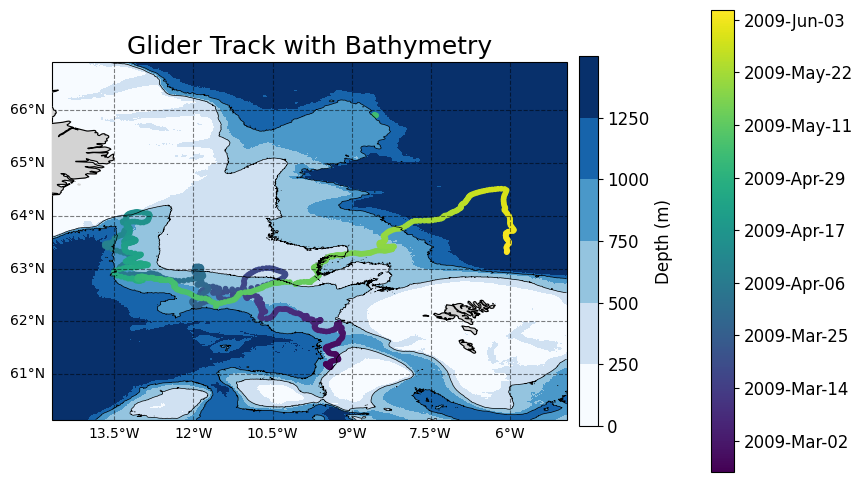

In [17]:
importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds)
display(fig)
### save the figure
#fig.savefig(mission_path + '/glider_track.png', dpi=300)
del fig, ax

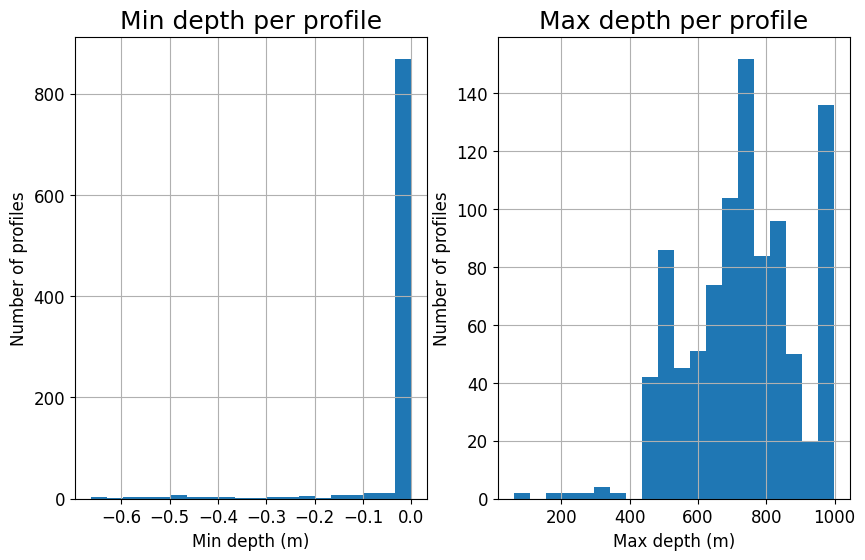

In [20]:
fig, ax = plotting.plot_min_max_depth(ds)
display(fig)
#fig.savefig(mission_path + '/min_max_histogram.png', dpi=300)
del fig, ax


### 2.2 Plot profiles interactively with the possibility of binning

In [21]:
profile_slider = widgets.SelectionSlider(options=np.unique(ds.PROFILE_NUMBER.values).astype(int), description='Profile number:', continuous_update=False)
raw_button = widgets.Checkbox(value=False, description='Raw data')
binning_slider = widgets.IntSlider(value=2, min=1, max=20, description='Binning (m):')
agg_button = widgets.ToggleButtons(options=['mean', 'median'],description='Aggregation:',disabled=False,button_style='')

In [70]:
interactive.interactive_profile(ds, profile_slider, raw_button)

interactive(children=(SelectionSlider(continuous_update=False, description='Profile number:', options=(np.int6…

In [37]:
interactive.interactive_resolution_hist(ds, profile_slider)

interactive(children=(SelectionSlider(continuous_update=False, description='Profile number:', index=491, optio…

In [23]:
interactive.interactive_profile_binned(ds, profile_slider, binning_slider, raw_button, agg_button)

interactive(children=(SelectionSlider(continuous_update=False, description='Profile number:', options=(np.int6…

### 2.3 Plot the MLD, depending on the settings that were chosen and add it in the next step to the dataset

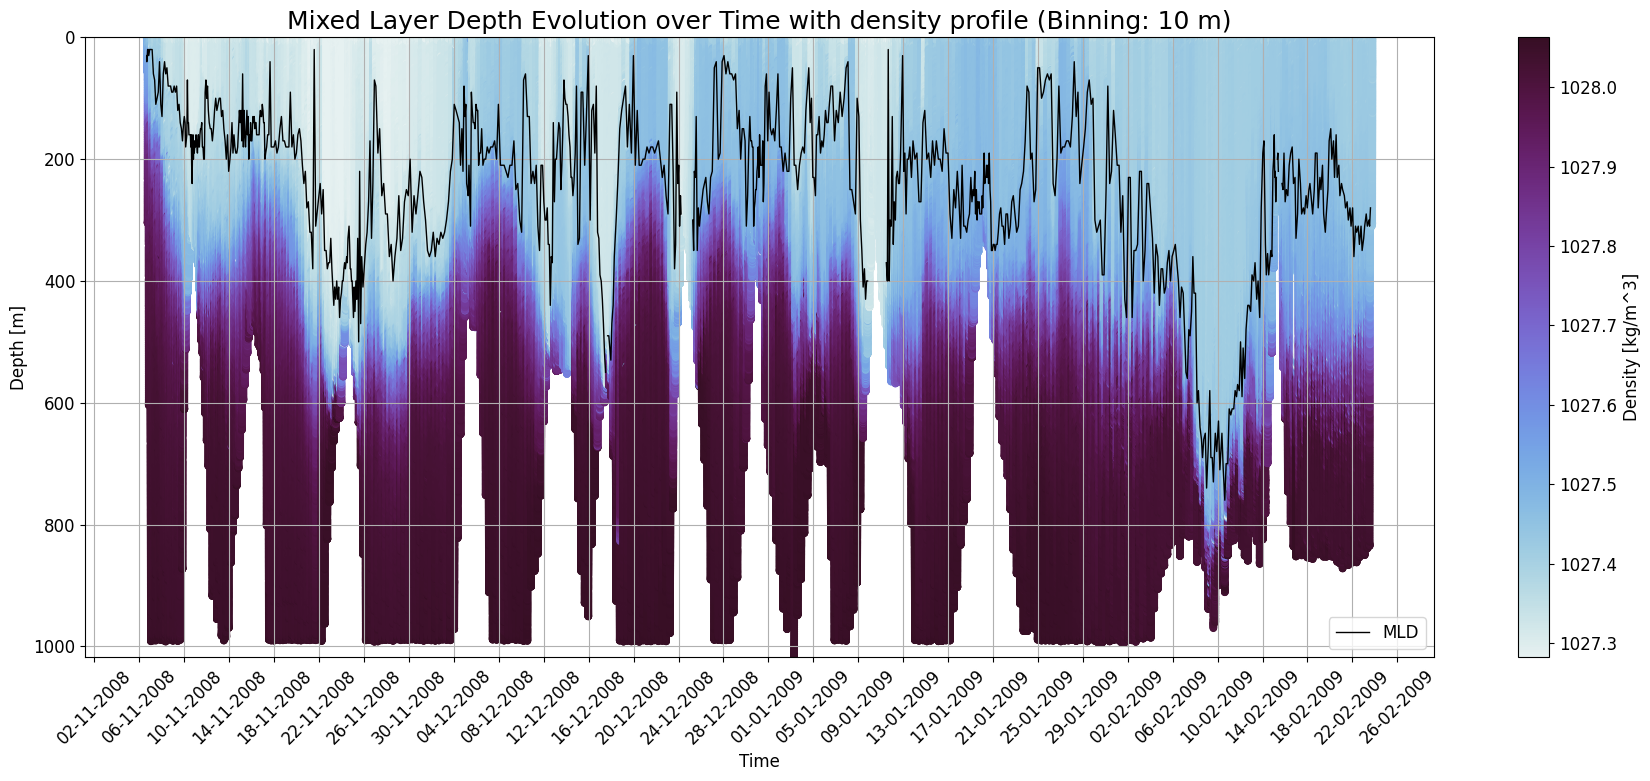

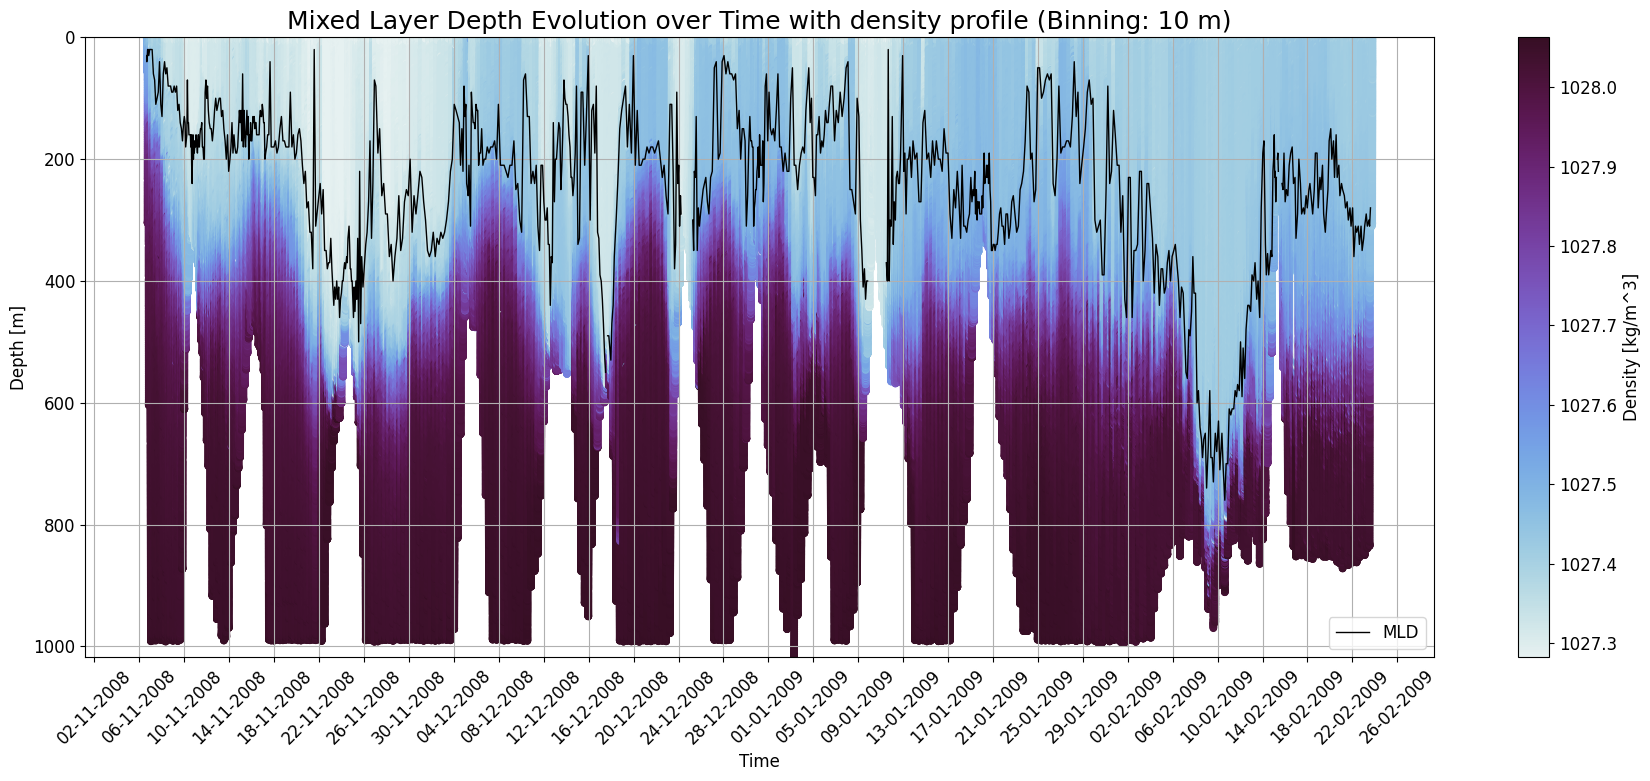

In [24]:
fig,ax = plotting.plot_MLD_evolution(ds,binning = 10,use_raw = False, plot_density= True)
display(fig)
#fig.savefig(mission_path + '/MLD_time_evolution.png', dpi=300)
del fig, ax

In [29]:
### add the MLD to the dataset for each profile
importlib.reload(reading)
importlib.reload(plotting)
importlib.reload(tools)
importlib.reload(interactive)
ds = tools.add_MLD_to_dataset(ds, use_bins=True, binning=10, use_raw=False)

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/tools.py:297: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  mld_array = np.full(ds.dims['N_MEASUREMENTS'], np.nan)
Calculating and adding MLD for Profiles: 100%|██████████| 970/970 [00:31<00:00, 30.49profile/s]


In [13]:
# Create sliders for longitude and latitude
default_coords = [[-14.0, 63.5], # First corner
                  [-13, 64.5], # Second corner
                  [-7.5, 62], # Third corner
                  [-9, 61]] # Fourth corner
# Create the interactive selector
get_region = plotting.interactive_region_selector(default_coords)

Button(description='Confirm Selection', style=ButtonStyle())

Output()

Region confirmed!


In [14]:
### get the coordinates of the region and create a new dataset with values only from this region
region = get_region()
ds_region = tools.cut_region(ds, region)

In [15]:
importlib.reload(interactive)
bad_profiles = interactive.interactive_bad_profile_checking(ds_region)

In [48]:
### cutting out profile numbers that are not needed
bad_profiles = np.array(bad_profiles)
ds = ds_region.isel(N_MEASUREMENTS=~np.isin(ds_region.PROFILE_NUMBER.values, bad_profiles))

/Users/tillmoritz/Desktop/Master_thesis/Git/dissipationSML/dissipationSML/plotting.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels([pd.to_datetime(t).strftime('%Y-%b-%d') for t in cbar.get_ticks()])


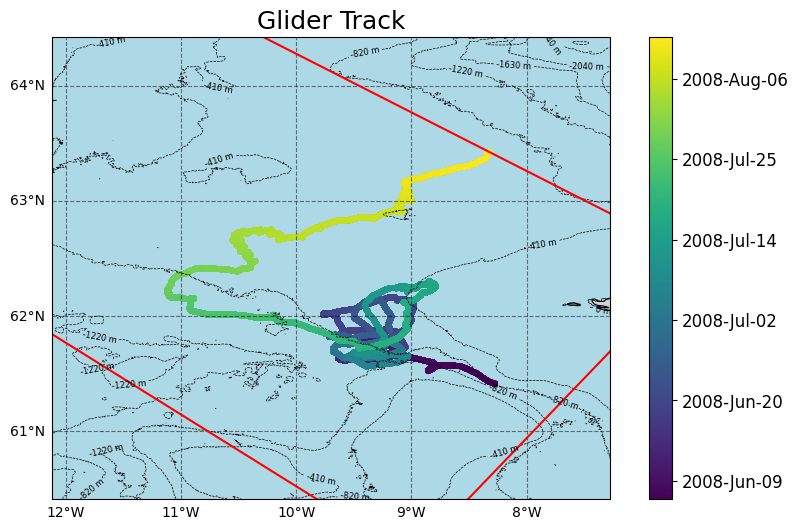

In [20]:
importlib.reload(plotting)
fig, ax = plotting.plot_glider_track(ds_region)
region.plot(ax=ax, add_label=False, line_kws={'color': 'red'})
display(fig)
#fig.savefig(mission_path + '/glider_track_region.png', dpi=300)
del fig, ax

In [ ]:
### save the dataset with MLD
#writers.save_dataset(ds, mission_path + '/all_data_OG1_with_MLD.nc')